In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import recall_score,precision_score,confusion_matrix,accuracy_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import pickle
import json


In [2]:
df = pd.read_csv('online_shoppers_intention.csv')

# Data Cleaning + Explorartory Data Analysis (EDA)

## First 5 rows of dataset

In [3]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


## Dimensions of Dataset

In [4]:
df.shape

(12330, 18)

- Dataset has 12330 rows
- Dataset has 18 columns

## Null values Checking

In [14]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


No null values are present in dataset


## Duplicate Value Checking

In [17]:
df.duplicated().sum()

np.int64(125)

125 duplicate values are present in the dataset 
we have to remove them 

## Removing Duplicate Values

In [3]:
df = df.drop_duplicates()

In [4]:
df.duplicated().sum()

np.int64(0)

Now all the duplicate values are removed from dataframe

## Column type checking

In [20]:
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [21]:
## Numerical columns
print("All Numerical columns are: ")
print(df.select_dtypes(include='number').columns)

All Numerical columns are: 
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')


In [ ]:
## Categorical columns
print("All Categorical columns are: ")
print(df.select_dtypes(include='object').columns)

All Categorical columns are: 
Index(['Month', 'VisitorType'], dtype='object')


In [7]:
## Bool columns
print("All Categorical columns are: ")
print(df.select_dtypes(include='bool').columns)

All Categorical columns are: 
Index(['Weekend', 'Revenue'], dtype='object')


## Statistical Summary of Data

In [24]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## Seperation of dependent and independent variables

In [10]:
x = df.drop(columns = ['Revenue'],axis = 1) # independent variables

In [13]:
x

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False


In [11]:
y = df['Revenue'] # dependent variables

In [15]:
y


0        False
1        False
2        False
3        False
4        False
         ...  
12325    False
12326    False
12327    False
12328    False
12329    False
Name: Revenue, Length: 12205, dtype: bool

## Plotting

### Numeric Columns VS Target

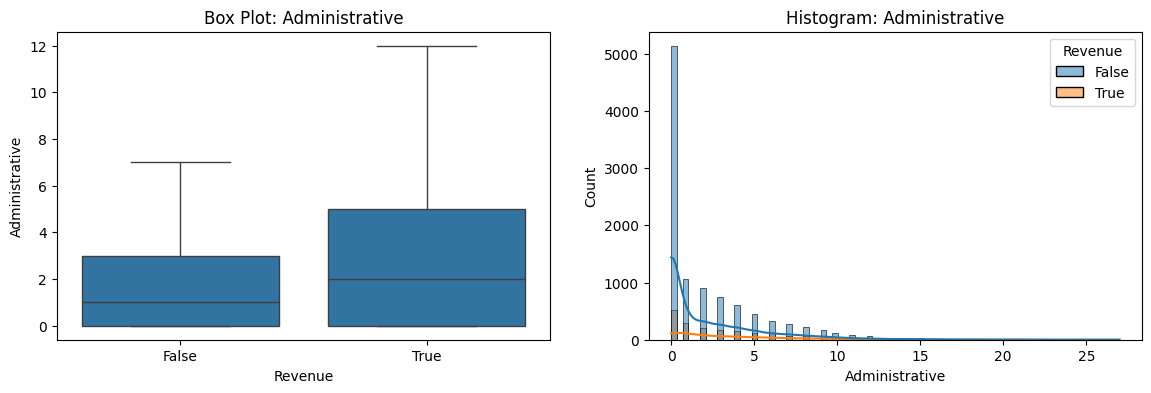

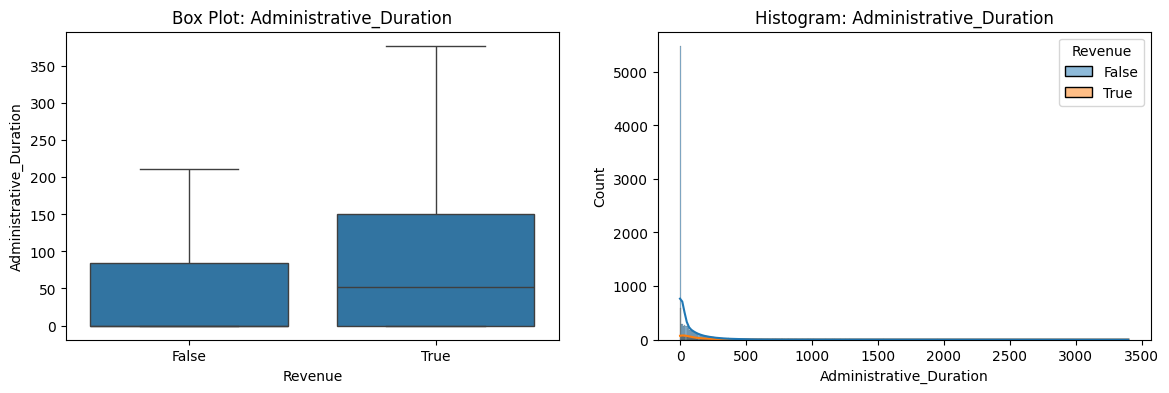

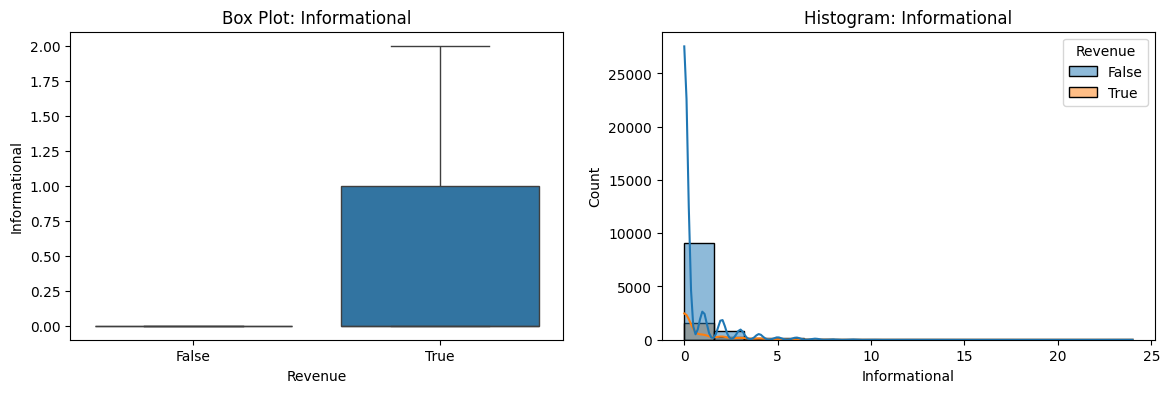

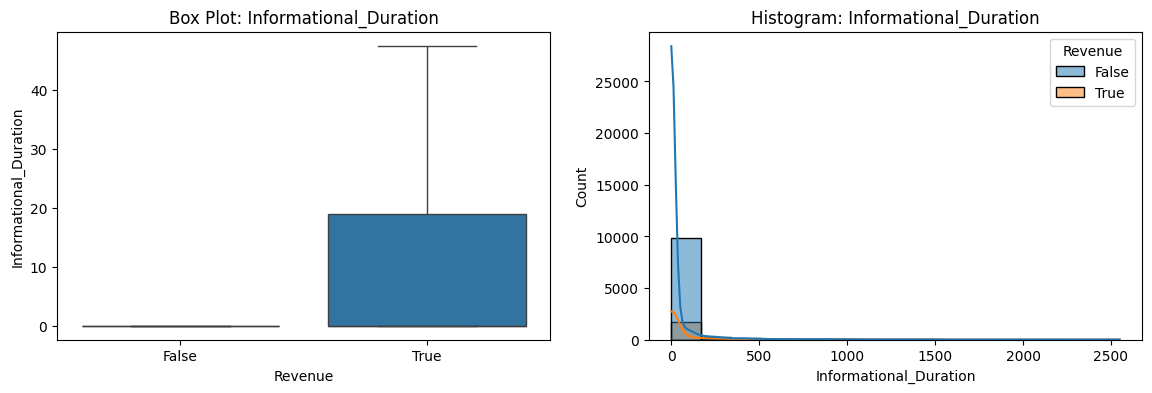

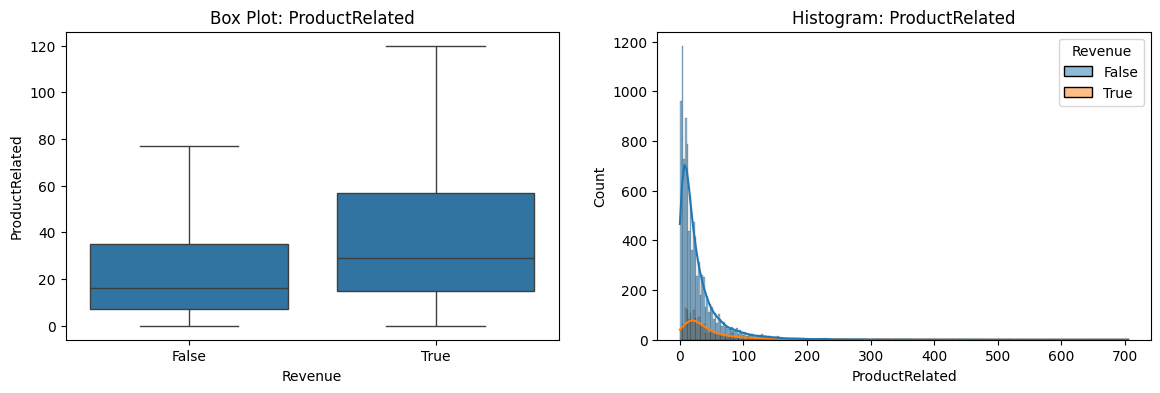

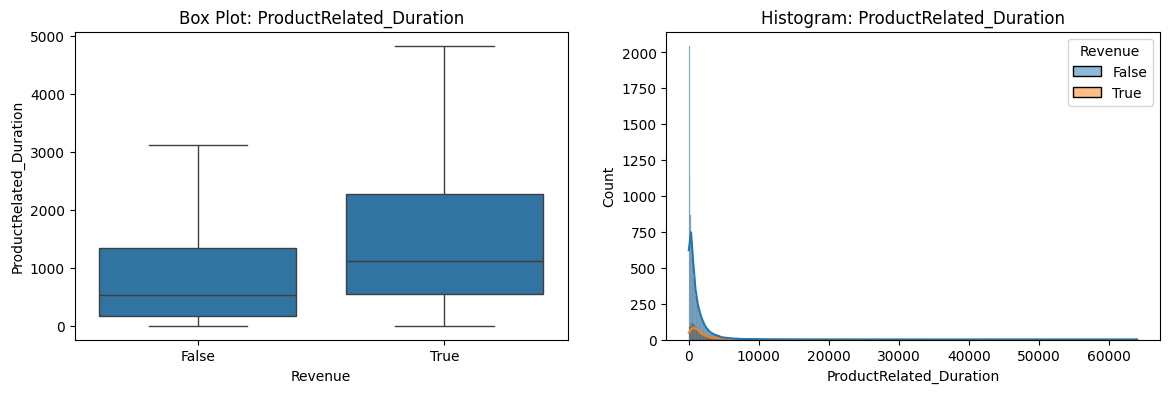

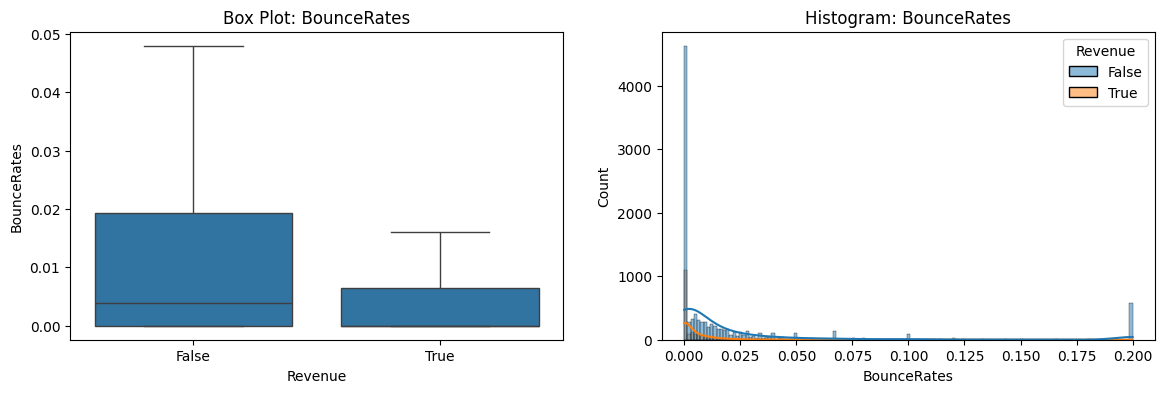

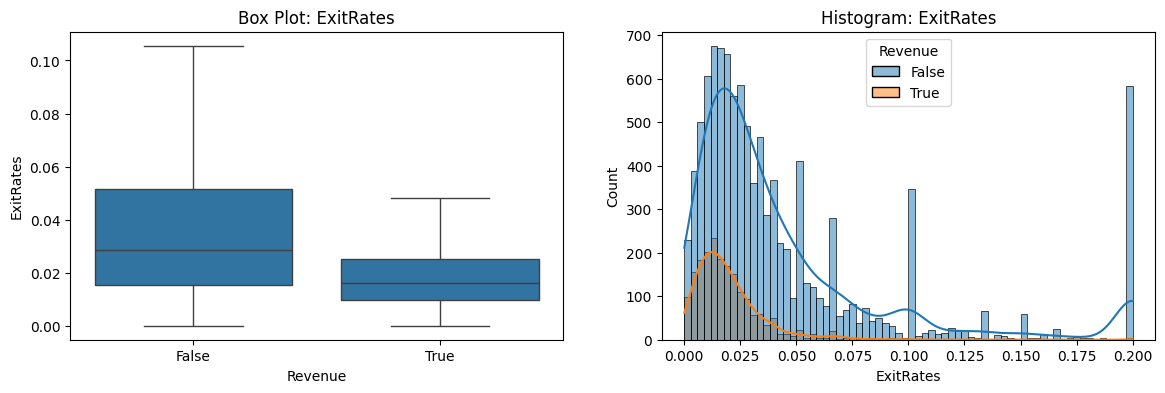

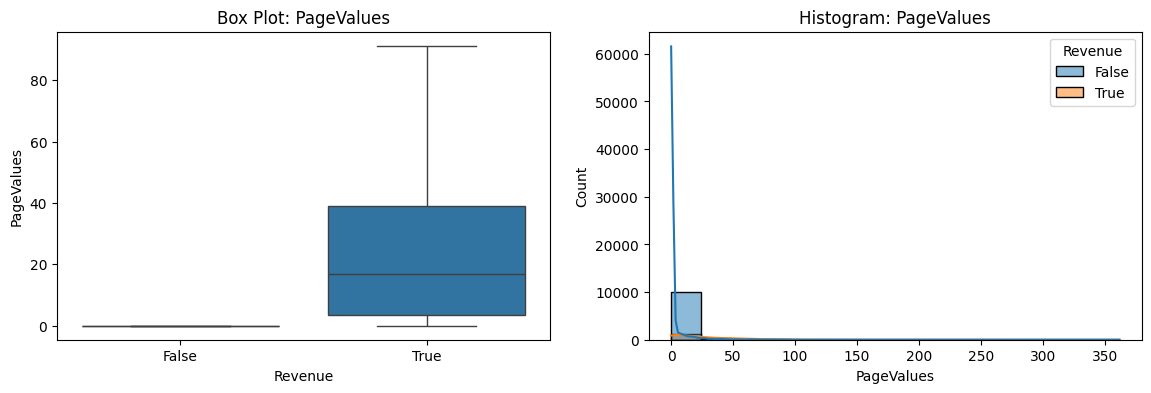

In [31]:
num_cols = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues']

for cols in num_cols:
    fig,axes = plt.subplots(1,2, figsize = (14,4))
    
    # Box plot
    sns.boxplot(x='Revenue',y = cols,data = df ,showfliers = False,ax=axes[0])
    axes[0].set_title(f'Box Plot: {cols}')
    
    # Histogram
    sns.histplot(data = df, x= cols, hue = 'Revenue', kde = True,ax=axes[1])
    axes[1].set_title(f'Histogram: {cols}')
    
    plt.show()

### Categorical Columns VS Target

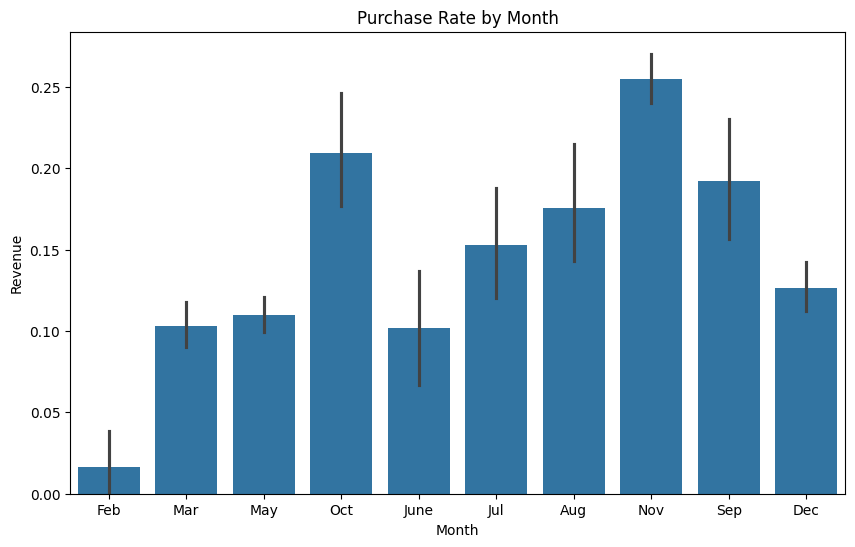

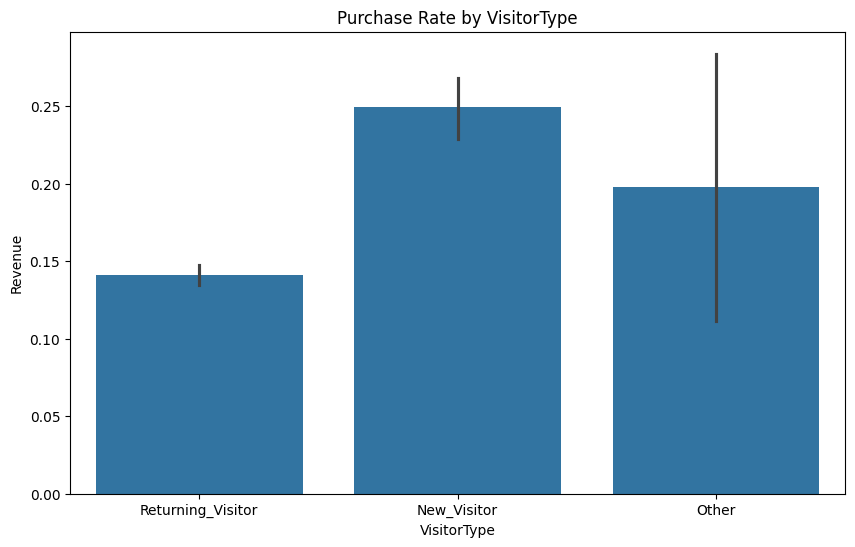

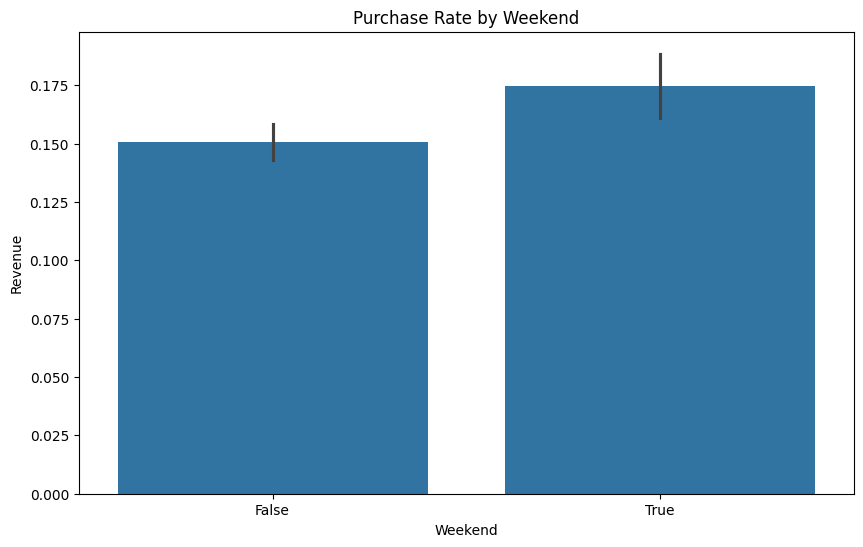

In [25]:
cat_cols = ['Month', 'VisitorType', 'Weekend']
for cols in cat_cols:
    plt.figure(figsize = (10,6))
    sns.barplot(data = df, x = cols, y = 'Revenue')
    plt.title(f"Purchase Rate by {cols}")
    plt.show()

### Correlation Heatmap

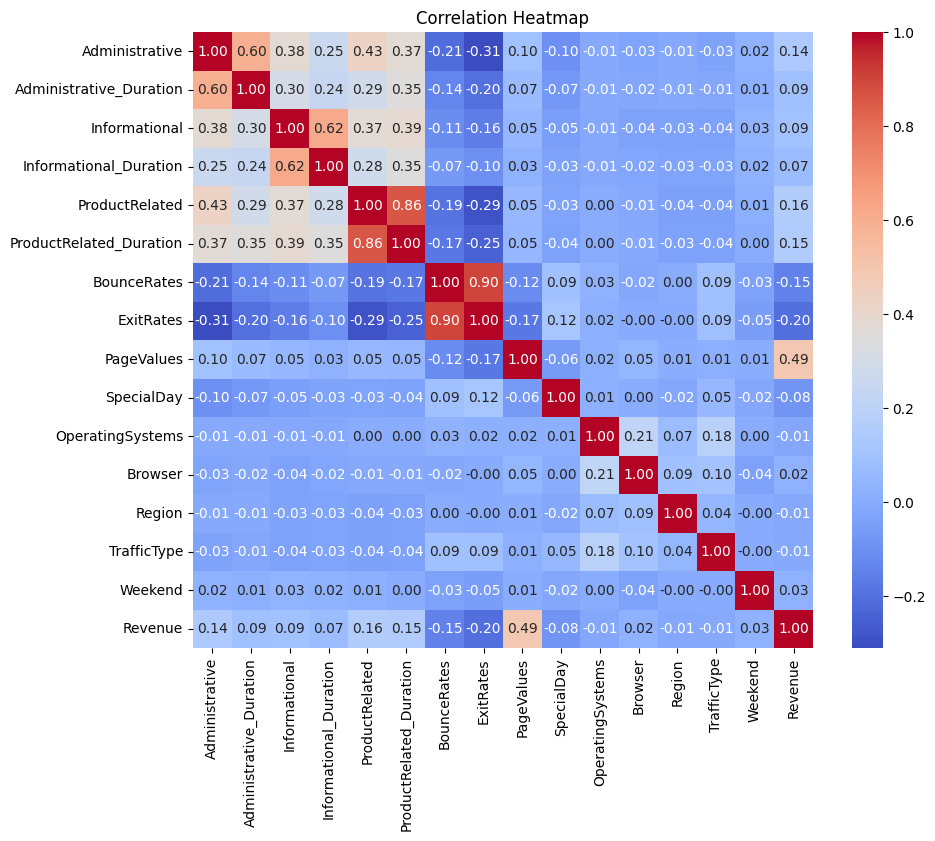

In [27]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot =True,fmt = '.2f',cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


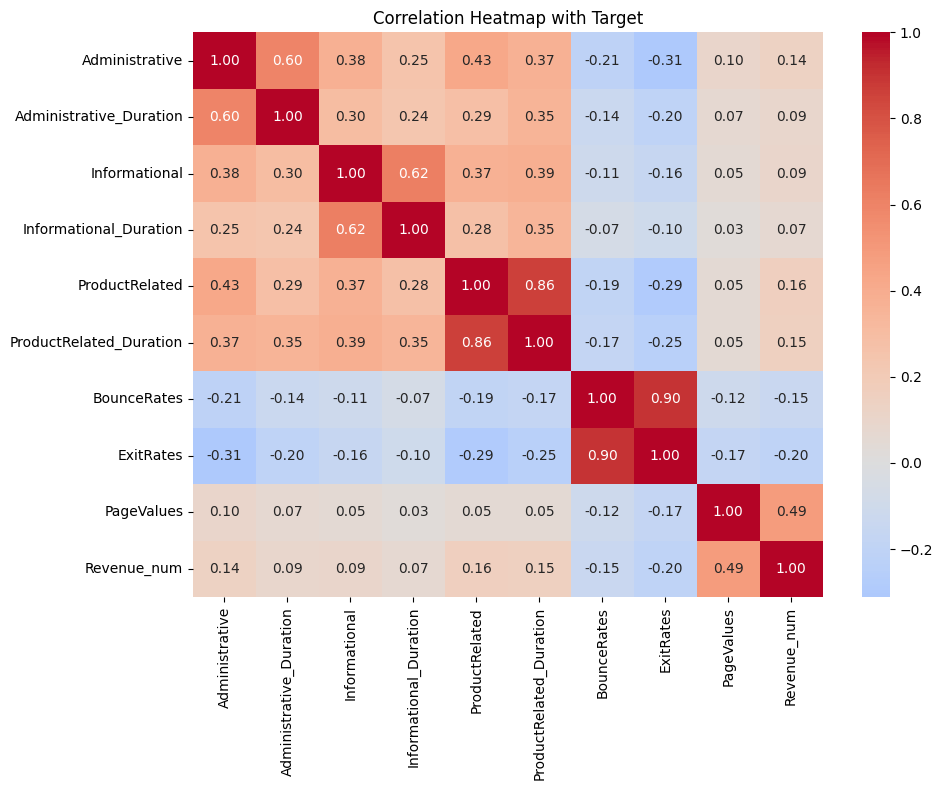

In [29]:
df['Revenue_num'] = df['Revenue'].astype(int)
num_cols = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues']

num_cols_with_target = num_cols + ['Revenue_num']
corr = df[num_cols_with_target].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap with Target')
plt.tight_layout()
plt.show()

## Checking Imbalance target

In [32]:
df['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

# Important Insights

- PageValues is higly Correlated with Revenue (correltion = 0.49)
- ProductRelated and ProductRelated_Duration are highly correlated with each other
- November is the month of high sale
- February is the month of low sale
- Purchase rate is highest for new visitors
- Purchase rate increases at weekends
- Outliers are present in every numerical column
- Targeted column is highly imbalanced

# Suggestions 

- ProductRelated and ProductRelated_Duration are highly correlated with each other so combine them and create a new feature
- Remove the outliers
- Convert the categorical columns in numericals by using encoding
- use SMOTE technique to convert imbalanced data into balanced one
- Create High Seasonal flags
- Create Page Value flags


# Feature Engineering

### PCA - to combine ProductRelated and ProductRelated_Duration

In [5]:
pca = PCA(n_components=1)
df['ProductEngagementPCA']=pca.fit_transform(df[['ProductRelated', 'ProductRelated_Duration']]) 

In [6]:
df = df.drop(columns = ['ProductRelated', 'ProductRelated_Duration'],axis = 1)

In [11]:
x

,Administrative,Administrative_Duration,Informational,Informational_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,ProductEngagementPCA
0,0,0.0,0,0.0,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,-1207.361845
1,0,0.0,0,0.0,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,-1143.354642
2,0,0.0,0,0.0,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,-1207.361845
3,0,0.0,0,0.0,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,-1204.675726
4,0,0.0,0,0.0,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,-579.807304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,577.112781
12326,0,0.0,0,0.0,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,-741.624924
12327,0,0.0,0,0.0,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,-1023.048718
12328,4,75.0,0,0.0,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,-861.151159


### Removing Outliers by IQR method

In [7]:
num_cols = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 
            'BounceRates', 'ExitRates', 'PageValues']

for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    IQR = q3 - q1
    
    lower_bound = q1-1.5*IQR
    upper_bound = q3+ 1.5*IQR
    df = df[(df[c] >= lower_bound) & (df[c] <= upper_bound)]

### Encoding

##### WEEKEND 

In [8]:
df['Weekend']=df['Weekend'].astype(int)

##### One HOT Encoding - Month and visitor type

In [9]:
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

In [16]:
x

,Administrative,Administrative_Duration,Informational,Informational_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
1,0,0.00,0,0.0,0.000000,0.100000,0.0,0.0,2,2,...,True,False,False,False,False,False,False,False,False,True
4,0,0.00,0,0.0,0.020000,0.050000,0.0,0.0,3,3,...,True,False,False,False,False,False,False,False,False,True
5,0,0.00,0,0.0,0.015789,0.024561,0.0,0.0,2,2,...,True,False,False,False,False,False,False,False,False,True
8,0,0.00,0,0.0,0.000000,0.100000,0.0,0.8,2,2,...,True,False,False,False,False,False,False,False,False,True
9,0,0.00,0,0.0,0.000000,0.022222,0.0,0.4,2,4,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12320,0,0.00,0,0.0,0.014286,0.050000,0.0,0.0,2,2,...,False,False,False,False,False,True,False,False,False,True
12323,2,64.75,0,0.0,0.000000,0.013953,0.0,0.0,2,2,...,False,False,False,False,False,True,False,False,False,True
12326,0,0.00,0,0.0,0.000000,0.021333,0.0,0.0,3,2,...,False,False,False,False,False,True,False,False,False,True
12328,4,75.00,0,0.0,0.000000,0.021053,0.0,0.0,2,2,...,False,False,False,False,False,True,False,False,False,True


## Train Test Splitting

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## SMOTE - Imbalanced Data Handling

In [15]:
smote = SMOTE(random_state=42)
x_train_balances,y_train_balance = smote.fit_resample(x_train,y_train)

In [16]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balance.value_counts())

Before SMOTE:
Revenue
False    4603
True      185
Name: count, dtype: int64

After SMOTE:
Revenue
False    4603
True     4603
Name: count, dtype: int64


## Model Training - XGBOOST

In [56]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Prediction

In [57]:
y_pred = xgb_model.predict(x_test)

## Model Evaluation

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9640768588137009
Precision: 0.3333333333333333
Recall: 0.10256410256410256
F1 Score: 0.1568627450980392


Text(0.5, 25.722222222222214, 'Predicted')

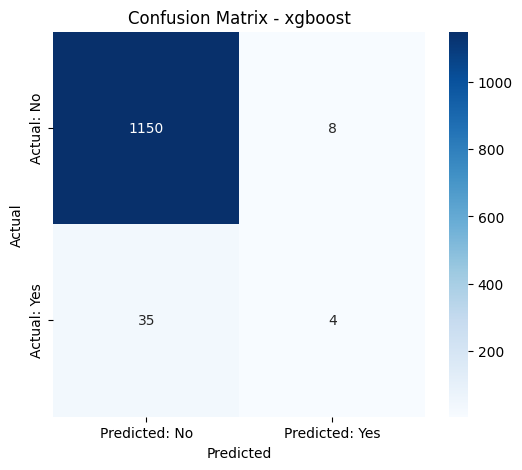

In [59]:
cm = confusion_matrix(y_test, y_pred)



plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix - xgboost')
plt.ylabel('Actual')
plt.xlabel('Predicted')

## Decision Tree Classifier

In [40]:
dt = DecisionTreeClassifier()
dt.fit(x_train_balances, y_train_balance)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
y_pred = dt.predict(x_test)

Text(0.5, 25.722222222222214, 'Predicted')

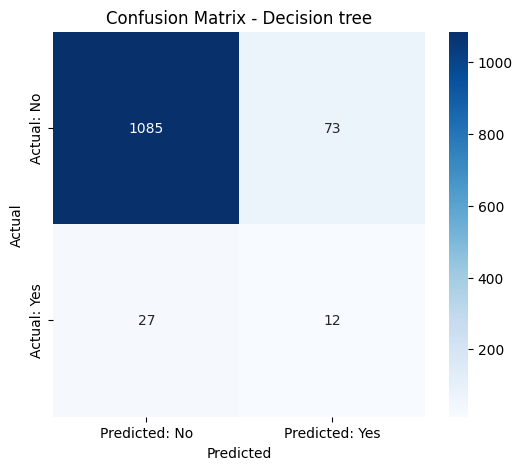

In [42]:
cm = confusion_matrix(y_test, y_pred)



plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix - Decision tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')

## Logistic Regression

In [43]:
lr = LogisticRegression()
lr.fit(x_train_balances, y_train_balance)

d:\Projects\Data Science\GetScry\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
y_pred = lr.predict(x_test)

Text(0.5, 25.722222222222214, 'Predicted')

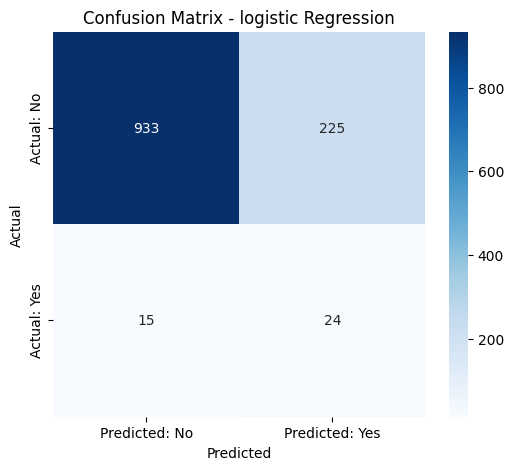

In [45]:
cm = confusion_matrix(y_test, y_pred)



plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix - logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')

## SVC

In [46]:
svc = SVC()
svc.fit(x_train_balances, y_train_balance)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [47]:
y_pred = svc.predict(x_test)

Text(0.5, 25.722222222222214, 'Predicted')

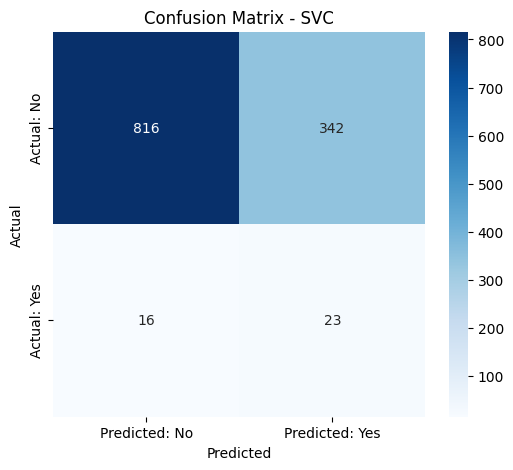

In [48]:
cm = confusion_matrix(y_test, y_pred)



plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix - SVC' )
plt.ylabel('Actual')
plt.xlabel('Predicted')

## hyperparameter tuning

In [60]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='recall',        # accuracy nahi, f1 use karein imbalance ke liye
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Recall Score:", random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(x_test)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best Recall Score: 0.06486486486486487


In [61]:
print(confusion_matrix(y_test, y_pred_tuned))

[[1144   14]
 [  36    3]]


## Threshold Tuning

In [63]:
y_proba = best_xgb.predict_proba(x_test)[:, 1]

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"\nThreshold {t}:")
    print(confusion_matrix(y_test, y_pred_t))
    #print(classification_report(y_test, y_pred_t))


Threshold 0.1:
[[1046  112]
 [  25   14]]

Threshold 0.2:
[[1100   58]
 [  28   11]]

Threshold 0.3:
[[1127   31]
 [  30    9]]

Threshold 0.4:
[[1137   21]
 [  34    5]]

Threshold 0.5:
[[1144   14]
 [  36    3]]


In [65]:
scale = (y_train==0).sum() / (y_train==1).sum()

xgb_weighted = XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric='logloss')
xgb_weighted.fit(x_train, y_train)  # no SMOTE

y_proba_w = xgb_weighted.predict_proba(x_test)[:, 1]
for t in [0.3, 0.4, 0.5]:
    y_pred_w = (y_proba_w >= t).astype(int)
    print(f"\nThreshold {t}:")
    print(confusion_matrix(y_test, y_pred_w))
    #print(classification_report(y_test, y_pred_w))


Threshold 0.3:
[[1099   59]
 [  26   13]]

Threshold 0.4:
[[1108   50]
 [  27   12]]

Threshold 0.5:
[[1113   45]
 [  29   10]]


In [67]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [5, 10, 15, 20, 25, 30]  # different values try karein
}

random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',   # recall ki bajaye ab f1 use karein, balanced result ke liye
    cv=5,
    n_jobs=-1,
    random_state=42
)
random_search.fit(x_train, y_train)   # SMOTE bina, original data
print("Best Params:", random_search.best_params_)
print("Best Recall Score:", random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred_tuned = best_xgb.predict(x_test)

Best Params: {'subsample': 0.7, 'scale_pos_weight': 10, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best Recall Score: 0.2453629740157314


In [69]:
print(confusion_matrix(y_test, y_pred_tuned))

[[1096   62]
 [  26   13]]


In [68]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
rf.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred = rf.predict(x_test)

In [71]:
print(confusion_matrix(y_test, y_pred))

[[1158    0]
 [  38    1]]


## Final Model

In [15]:

scale = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale pos weight:", scale)


final_model = XGBClassifier(
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)

final_model.fit(x_train, y_train)


#  Predictions with chosen threshold (0.3)

y_proba = final_model.predict_proba(x_test)[:, 1]

threshold = 0.3   
y_pred = (y_proba >= threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Scale pos weight: 24.88108108108108
Confusion Matrix:
[[1099   59]
 [  26   13]]


## Model Saving

In [16]:
with open('xgb_final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

## Saving Config

In [18]:
model_config = {
    "threshold": threshold,
    "scale_pos_weight": float(scale)
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f)

